# Proyecto 2 — Análisis Inicial y Selección de Problema

**Etapa:** Parte I — Búsqueda, EDA inicial y Selección de Problema  

---

##Datasets analizados

| # | Dataset | Fuente | Dominio | Problema |
|---|---------|--------|---------|----------|
| 1 | Bank Customer Churn | Kaggle | Banca / Finanzas | Clasificación |
| 2 | Heart Disease | Kaggle | Salud / Medicina | Clasificación |
| 3 | Video Game Sales + Metacritic | Kaggle | Entretenimiento | Regresión |
| 4 | Most Streamed Spotify Songs 2024 | Kaggle | Música / Streaming | Regresión |

---


# Diccionario de Columnas — Proyecto 2
---

## Dataset 4 — Most Streamed Spotify Songs 2024
**Archivo:** `Most_Streamed_Spotify_Songs_2024.csv` | **Filas:** 4.600 | **Columnas:** 29

| # | Columna (original) | Traducción | Tipo | Descripción |
|---|---|---|---|---|
| 1 | Track | Canción | str | Nombre de la canción |
| 2 | Album Name | Nombre del álbum | str | Nombre del álbum al que pertenece la canción |
| 3 | Artist | Artista | str | Nombre del artista o artistas de la canción |
| 4 | Release Date | Fecha de lanzamiento | str | Fecha en que fue lanzada la canción |
| 5 | ISRC | Código ISRC | str | Código Internacional Estándar de Grabación — identificador único de la canción |
| 6 | All Time Rank | Ranking histórico | int | Posición de la canción basada en su popularidad histórica acumulada |
| 7 | Track Score | Puntuación de la pista | float | Puntuación compuesta asignada a la canción según múltiples factores de popularidad |
| 8 | **Spotify Streams** | **Streams en Spotify** | str* | **Variable objetivo: número total de reproducciones en Spotify** |
| 9 | Spotify Playlist Count | N° de playlists en Spotify | str* | Cantidad de playlists de Spotify que incluyen la canción |
| 10 | Spotify Playlist Reach | Alcance en playlists de Spotify | str* | Alcance estimado de la canción a través de las playlists de Spotify |
| 11 | Spotify Popularity | Popularidad en Spotify | int | Índice de popularidad actual en Spotify (0–100) |
| 12 | YouTube Views | Vistas en YouTube | str* | Total de reproducciones del video en YouTube |
| 13 | YouTube Likes | Likes en YouTube | str* | Total de likes recibidos en YouTube |
| 14 | TikTok Posts | Posts en TikTok | str* | Cantidad de videos publicados en TikTok usando la canción |
| 15 | TikTok Likes | Likes en TikTok | str* | Total de likes en los videos de TikTok que usan la canción |
| 16 | TikTok Views | Vistas en TikTok | str* | Total de reproducciones de videos de TikTok que usan la canción |
| 17 | YouTube Playlist Reach | Alcance en playlists de YouTube | str* | Alcance estimado de la canción a través de playlists de YouTube |
| 18 | Apple Music Playlist Count | N° de playlists en Apple Music | int | Cantidad de playlists de Apple Music que incluyen la canción |
| 19 | AirPlay Spins | Emisiones en AirPlay | str* | Número de veces que la canción fue emitida en radio vía AirPlay |
| 20 | SiriusXM Spins | Emisiones en SiriusXM | int | Número de veces que la canción fue emitida en la radio SiriusXM |
| 21 | Deezer Playlist Count | N° de playlists en Deezer | int | Cantidad de playlists de Deezer que incluyen la canción |
| 22 | Deezer Playlist Reach | Alcance en playlists de Deezer | str* | Alcance estimado de la canción a través de playlists de Deezer |
| 23 | Amazon Playlist Count | N° de playlists en Amazon Music | int | Cantidad de playlists de Amazon Music que incluyen la canción |
| 24 | Pandora Streams | Streams en Pandora | str* | Número total de reproducciones en la plataforma Pandora |
| 25 | Pandora Track Stations | Estaciones de Pandora | str* | Cantidad de estaciones de radio en Pandora donde aparece la canción |
| 26 | Soundcloud Streams | Streams en Soundcloud | str* | Número total de reproducciones en Soundcloud |
| 27 | Shazam Counts | Búsquedas en Shazam | str* | Número de veces que la canción fue identificada mediante Shazam |
| 28 | TIDAL Popularity | Popularidad en TIDAL | float | Índice de popularidad de la canción en la plataforma TIDAL |
| 29 | Explicit Track | Contenido explícito | int | Indica si la canción tiene contenido explícito (1 = Sí / 0 = No) |

---


---
# Sección 0 — Configuración del entorno

Lo primero que debemos hacer es conectarnos al drive para poder acceder a los dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Librerías
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [ ]:
#  Función reutilizable: resumen de nulos
def resumen_nulos(df, titulo=''):
    null_df = pd.DataFrame({
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / len(df) * 100).round(1)
    }).sort_values('% Nulos', ascending=False)
    null_df = null_df[null_df['Nulos'] > 0]
    if null_df.empty:
        print(f'{titulo}: Sin valores nulos.')
        return null_df
    print(f'\n Nulos en {titulo}:')
    print(null_df.to_string())
    return null_df

# Función reutilizable: outliers IQR
def resumen_outliers(df, cols, nombre=''):
    rows = []
    for col in cols:
        if col not in df.columns: continue
        data = df[col].dropna()
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        n = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
        rows.append({
            'Variable': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
            'IQR': round(IQR, 2), 'N Outliers': n,
            '% Outliers': round(n / len(data) * 100, 2)
        })
    result = pd.DataFrame(rows)
    if not result.empty:
        print(f'\n [{nombre}] Resumen de outliers (método IQR):')
        display(result)
    return result


---
# Dataset 4 — Most Streamed Spotify Songs 2024
**Fuente:** Kaggle — `nelgiriyewithana/most-streamed-spotify-songs-2024`  
**Dominio:** Música / Streaming  
**Problema:** Regresión — predecir streams en Spotify

## 4.1 Descripción del conjunto de datos
casi 4.600 canciones más escuchadas en Spotify 2024 con métricas de 6+ plataformas.  
 **Advertencia:** columnas numéricas almacenadas como strings con comas (`'390,470,936'`) — requieren conversión obligatoria antes de cualquier análisis.

| Columna | Traducción | Tipo real | Descripción |
|---|---|---|---|
| Track | Canción | str | Nombre de la canción |
| Album Name | Álbum | str | Nombre del álbum |
| Artist | Artista | str | Nombre del artista(s) |
| Release Date | Fecha de lanzamiento | str→date | Fecha de lanzamiento |
| ISRC | Código ISRC | str | Identificador único de grabación |
| All Time Rank | Ranking histórico | int | Posición por popularidad histórica |
| Track Score | Puntuación | float | Puntuación compuesta de popularidad |
| **Spotify Streams** | **Streams Spotify** | str*→int | **Target: reproducciones totales** |
| Spotify Playlist Count | Playlists Spotify | str*→int | N° de playlists que incluyen la canción |
| Spotify Playlist Reach | Alcance playlists | str*→int | Alcance estimado en playlists |
| Spotify Popularity | Popularidad Spotify | int | Índice de popularidad (0–100) |
| YouTube Views | Vistas YouTube | str*→int | Total de reproducciones en YouTube |
| YouTube Likes | Likes YouTube | str*→int | Total de likes en YouTube |
| TikTok Posts | Posts TikTok | str*→int | Videos publicados usando la canción |
| TikTok Likes | Likes TikTok | str*→int | Likes en videos de TikTok |
| TikTok Views | Vistas TikTok | str*→int | Reproducciones en TikTok |
| YouTube Playlist Reach | Alcance playlists YT | str*→int | Alcance en playlists de YouTube |
| Apple Music Playlist Count | Playlists Apple Music | int | N° de playlists en Apple Music |
| AirPlay Spins | Emisiones AirPlay | str*→int | Emisiones de radio vía AirPlay |
| SiriusXM Spins | Emisiones SiriusXM | int | Emisiones en radio SiriusXM |
| Deezer Playlist Count | Playlists Deezer | int | N° de playlists en Deezer |
| Deezer Playlist Reach | Alcance Deezer | str*→int | Alcance en playlists de Deezer |
| Amazon Playlist Count | Playlists Amazon | int | N° de playlists en Amazon Music |
| Pandora Streams | Streams Pandora | str*→int | Reproducciones en Pandora |
| Pandora Track Stations | Estaciones Pandora | str*→int | Estaciones de radio en Pandora |
| Soundcloud Streams | Streams Soundcloud | str*→int | Reproducciones en Soundcloud |
| Shazam Counts | Búsquedas Shazam | str*→int | Identificaciones mediante Shazam |
| TIDAL Popularity | Popularidad TIDAL | float | Índice de popularidad en TIDAL |
| Explicit Track | Contenido explícito | int | 1 = Sí / 0 = No |

*Almacenadas como string con separadores de miles — se convierten en la sección 4.2

## 4.2 Descarga y carga de datos

In [ ]:
df_spotify = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/Most Streamed Spotify Songs 2024.csv', encoding='latin-1')
#esto de encoding tuve que buscarlo con la Ia, ya que tenia problemas con caracteres que no eran UTF-8 (eran caracteres especiales)
print(f'df_spotify cargado (antes de limpieza): {df_spotify.shape[0]:,} filas × {df_spotify.shape[1]} columnas')
print(f'Columnas: {df_spotify.columns.tolist()}')
df_spotify.head()

df_spotify cargado (antes de limpieza): 4,600 filas × 29 columnas
Columnas: ['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC', 'All Time Rank', 'Track Score', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Count', 'Deezer Playlist Reach', 'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity', 'Explicit Track']


,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


## 4.2.1 Análisis estadístico descriptivo

In [ ]:
print(f'Informacion del dataset: \n')
df_spotify.info()

print(f'\nPrimeras 5 filas: \n\n {df_spotify.head()}\n')
print(f'Últimas 5 filas: \n\n {df_spotify.tail()}\n')
print(f'Cantidad de elementos duplicados:\n\n {df_spotify.duplicated()}\n')
print(f'Cantidad de elementos nulos:\n \n{df_spotify.isnull().sum()}\n')
print(f'Tipos de datos :\n \n {df_spotify.dtypes.to_string()}')
num4 = df_spotify.select_dtypes(include=np.number)
desc4 = num4.describe().T
desc4['skewness'] = num4.skew().round(2)
desc4['% nulos'] = (num4.isnull().mean()*100).round(1)
display(desc4[['count','mean','std','min','50%','max','skewness','% nulos']]
        .style.background_gradient(cmap='YlOrRd', subset=['skewness','% nulos']))

Informacion del dataset: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Track                       4600 non-null   object 
 1   Album Name                  4600 non-null   object 
 2   Artist                      4595 non-null   object 
 3   Release Date                4600 non-null   object 
 4   ISRC                        4600 non-null   object 
 5   All Time Rank               4600 non-null   object 
 6   Track Score                 4600 non-null   float64
 7   Spotify Streams             4487 non-null   object 
 8   Spotify Playlist Count      4530 non-null   object 
 9   Spotify Playlist Reach      4528 non-null   object 
 10  Spotify Popularity          3796 non-null   float64
 11  YouTube Views               4292 non-null   object 
 12  YouTube Likes               4285 non-null   object 
 13  TikTok

,count,mean,std,min,50%,max,skewness,% nulos
Track Score,4600.000000,41.844043,38.543766,19.400000,29.900000,725.400000,5.690000,0.000000
Spotify Popularity,3796.000000,63.501581,16.186438,1.000000,67.000000,96.000000,-2.050000,17.500000
Apple Music Playlist Count,4039.000000,54.603120,71.612270,1.000000,28.000000,859.000000,2.890000,12.200000
Deezer Playlist Count,3679.000000,32.310954,54.274538,1.000000,15.000000,632.000000,4.790000,20.000000
Amazon Playlist Count,3545.000000,25.348942,25.989826,1.000000,17.000000,210.000000,2.190000,22.900000
TIDAL Popularity,0.000000,nan,nan,nan,nan,nan,nan,100.000000
Explicit Track,4600.000000,0.358913,0.479734,0.000000,0.000000,1.000000,0.590000,0.000000


## 4.2.2 Tipos de datos y conversiones

Esto debemos hacerlo porque existen muchos datos con comas entremedio siendo que son numericos

In [ ]:
print(' Tipos de datos originales')
print(df_spotify.dtypes.to_string())

# Columnas numéricas almacenadas como strings con comas
cols_to_convert = [
    'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach',
    'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views',
    'YouTube Playlist Reach', 'AirPlay Spins', 'Deezer Playlist Reach',
    'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'Shazam Counts'
]

converted_spotify = []
for col in cols_to_convert:
    if col in df_spotify.columns:
        df_spotify[col] = pd.to_numeric(
            df_spotify[col].astype(str).str.replace(',', '').str.replace(' ', '').str.strip(),
            errors='coerce'
        )
        converted_spotify.append(col)

# Convertir Release Date a datetime y extraer año/mes
if 'Release Date' in df_spotify.columns:
    df_spotify['Release Date'] = pd.to_datetime(df_spotify['Release Date'], errors='coerce')
    df_spotify['Release Year']  = df_spotify['Release Date'].dt.year
    df_spotify['Release Month'] = df_spotify['Release Date'].dt.month

print(f'\n{len(converted_spotify)} columnas convertidas a numérico')
print(' Tipos de datos tras conversión')
print(df_spotify.dtypes.to_string())

 Tipos de datos originales
Track                          object
Album Name                     object
Artist                         object
Release Date                   object
ISRC                           object
All Time Rank                  object
Track Score                   float64
Spotify Streams                object
Spotify Playlist Count         object
Spotify Playlist Reach         object
Spotify Popularity            float64
YouTube Views                  object
YouTube Likes                  object
TikTok Posts                   object
TikTok Likes                   object
TikTok Views                   object
YouTube Playlist Reach         object
Apple Music Playlist Count    float64
AirPlay Spins                  object
SiriusXM Spins                 object
Deezer Playlist Count         float64
Deezer Playlist Reach          object
Amazon Playlist Count         float64
Pandora Streams                object
Pandora Track Stations         object
Soundcloud Streams     

## 4.3 Valores nulos

In [ ]:
nulos_spotify = resumen_nulos(df_spotify, 'df_spotify')

if not nulos_spotify.empty:
    print('\nEstrategia de tratamiento:')
    for col, row in nulos_spotify.iterrows():
        if row['% Nulos'] > 50:
            print(f'  {col} ({row["% Nulos"]}%): alta tasa, entonces considerar eliminar')
        elif df_spotify[col].dtype == 'object':
            print(f'  {col} ({row["% Nulos"]}%): imputar con moda')
        else:
            print(f'  {col} ({row["% Nulos"]}%): imputar con mediana')



 Nulos en df_spotify:
                            Nulos  % Nulos
TIDAL Popularity             4600    100.0
Soundcloud Streams           3333     72.5
SiriusXM Spins               2123     46.2
Pandora Track Stations       1268     27.6
TikTok Posts                 1173     25.5
Pandora Streams              1106     24.0
Amazon Playlist Count        1055     22.9
YouTube Playlist Reach       1009     21.9
TikTok Views                  981     21.3
TikTok Likes                  980     21.3
Deezer Playlist Reach         928     20.2
Deezer Playlist Count         921     20.0
Spotify Popularity            804     17.5
Shazam Counts                 577     12.5
Apple Music Playlist Count    561     12.2
AirPlay Spins                 498     10.8
YouTube Likes                 315      6.8
YouTube Views                 308      6.7
Spotify Streams               113      2.5
Spotify Playlist Reach         72      1.6
Spotify Playlist Count         70      1.5
Artist                         

In [ ]:
nulos_spotify = resumen_nulos(df_spotify, 'df_spotify')

if not nulos_spotify.empty:
    print('\n💡 Estrategia de tratamiento:')
    for col, row in nulos_spotify.iterrows():
        if row['% Nulos'] > 50:
            print(f'  {col} ({row["% Nulos"]}%): alta tasa → considerar eliminar')
        elif df_spotify[col].dtype == 'object':
            print(f'  {col} ({row["% Nulos"]}%): imputar con moda')
        else:
            print(f'  {col} ({row["% Nulos"]}%): imputar con mediana')
    print('\n💡 Nota: nulos en plataformas secundarias (Pandora, Soundcloud) son')
    print('   esperables — no todas las canciones están disponibles en todas las plataformas.')

## 4.4 Duplicados

In [ ]:
n_dup_spotify = df_spotify.duplicated(subset=['Track', 'Artist', 'ISRC']).sum()
print(f'Filas con Track+Artist+ISRC duplicados: {n_dup_spotify}')

n_dup_full = df_spotify.duplicated().sum()
print(f'Filas completamente duplicadas: {n_dup_full}')

if n_dup_full > 0:
    df_spotify.drop_duplicates(inplace=True)
    df_spotify.reset_index(drop=True, inplace=True)
    print(f'Duplicados eliminados. Shape actual: {df_spotify.shape}')
else:
    print('Sin filas duplicadas.')

Filas con Track+Artist+ISRC duplicados: 2
Filas completamente duplicadas: 2
Duplicados eliminados. Shape actual: (4598, 31)


## 4.5 Estadísticas descriptivas (datos limpios)

In [ ]:
num_spotify = df_spotify.select_dtypes(include=np.number)
desc_spotify = num_spotify.describe().T
desc_spotify['skewness'] = num_spotify.skew().round(2)
desc_spotify['% nulos'] = (num_spotify.isnull().mean() * 100).round(1)
display(desc_spotify[['count', 'mean', 'std', 'min', '50%', 'max', 'skewness', '% nulos']]
        .style.background_gradient(cmap='YlOrRd', subset=['skewness', '% nulos']))

,count,mean,std,min,50%,max,skewness,% nulos
Track Score,4598.000000,41.850892,38.550706,19.400000,29.900000,725.400000,5.690000,0.000000
Spotify Streams,4485.000000,447406866.923746,538550400.792155,1071.000000,239850720.000000,4281468720.000000,2.020000,2.500000
Spotify Playlist Count,4528.000000,59397.509496,71145.599503,1.000000,32312.500000,590392.000000,1.840000,1.500000
Spotify Playlist Reach,4526.000000,23351766.968626,29692793.807118,1.000000,13264111.500000,262343414.000000,2.600000,1.600000
Spotify Popularity,3794.000000,63.498682,16.189952,1.000000,67.000000,96.000000,-2.050000,17.500000
YouTube Views,4290.000000,402784101.121445,702010524.654422,913.000000,148269610.000000,16322756555.000000,6.020000,6.700000
YouTube Likes,4283.000000,2930658.979921,4594517.419041,25.000000,1257935.000000,62311179.000000,4.220000,6.900000
TikTok Posts,3425.000000,944811.708905,2442703.581551,1.000000,182529.000000,42900000.000000,7.630000,25.500000
TikTok Likes,3618.000000,112690186.592869,549959736.061711,3.000000,26576921.500000,23474223833.000000,32.050000,21.300000
TikTok Views,3617.000000,1161723536.329002,5883160614.981201,19.000000,266064027.000000,233232311463.000000,31.010000,21.300000


## 4.6 Distribuciones / Histogramas

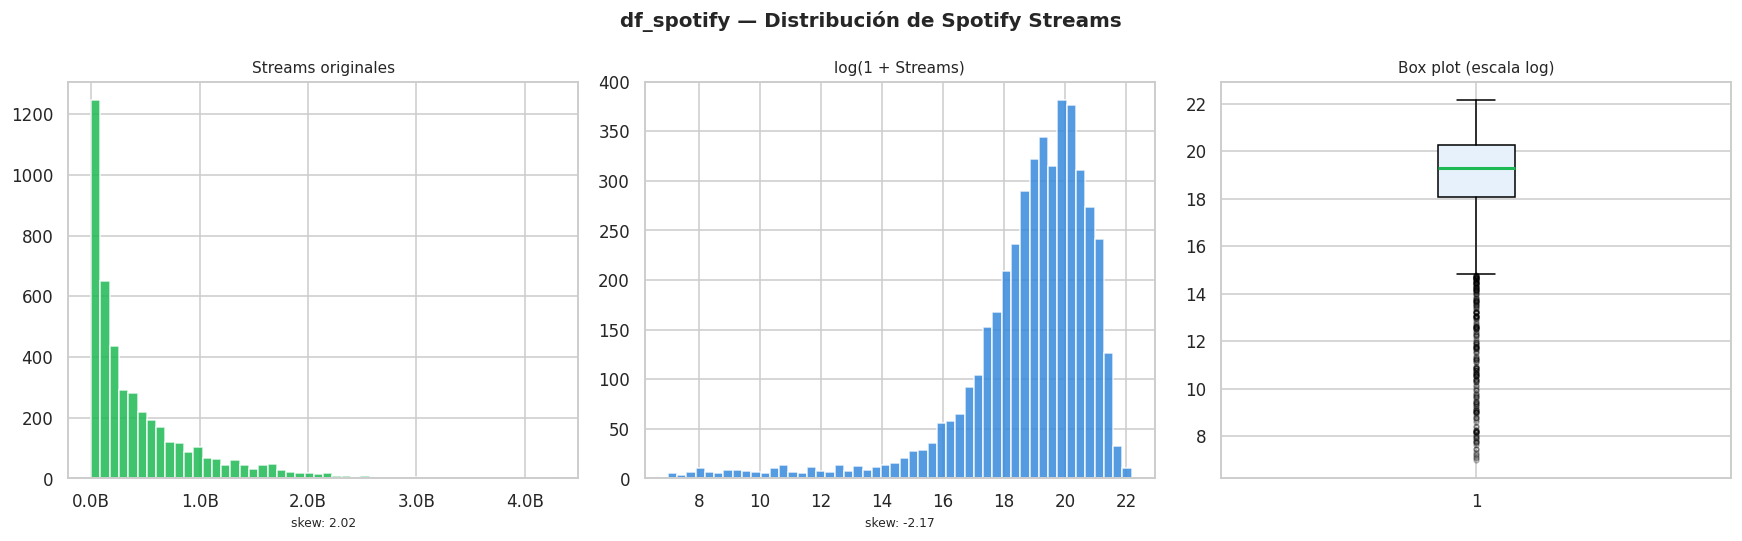

In [ ]:
# Distribución de Spotify Streams: original vs log
stream_col = 'Spotify Streams'
streams = df_spotify[stream_col].dropna()
streams_log = np.log1p(streams)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(streams, bins=50, color='#1DB954', edgecolor='white', alpha=0.85)
axes[0].set_title('Streams originales', fontsize=10)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
axes[0].set_xlabel(f'skew: {streams.skew():.2f}', fontsize=8)

axes[1].hist(streams_log, bins=50, color='#378ADD', edgecolor='white', alpha=0.85)
axes[1].set_title('log(1 + Streams)', fontsize=10)
axes[1].set_xlabel(f'skew: {streams_log.skew():.2f}', fontsize=8)

axes[2].boxplot(streams_log, patch_artist=True,
                boxprops=dict(facecolor='#E6F1FB'),
                medianprops=dict(color='#1DB954', linewidth=2),
                flierprops=dict(marker='.', alpha=0.3, color='#D85A30'))
axes[2].set_title('Box plot (escala log)', fontsize=10)

plt.suptitle('df_spotify — Distribución de Spotify Streams', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

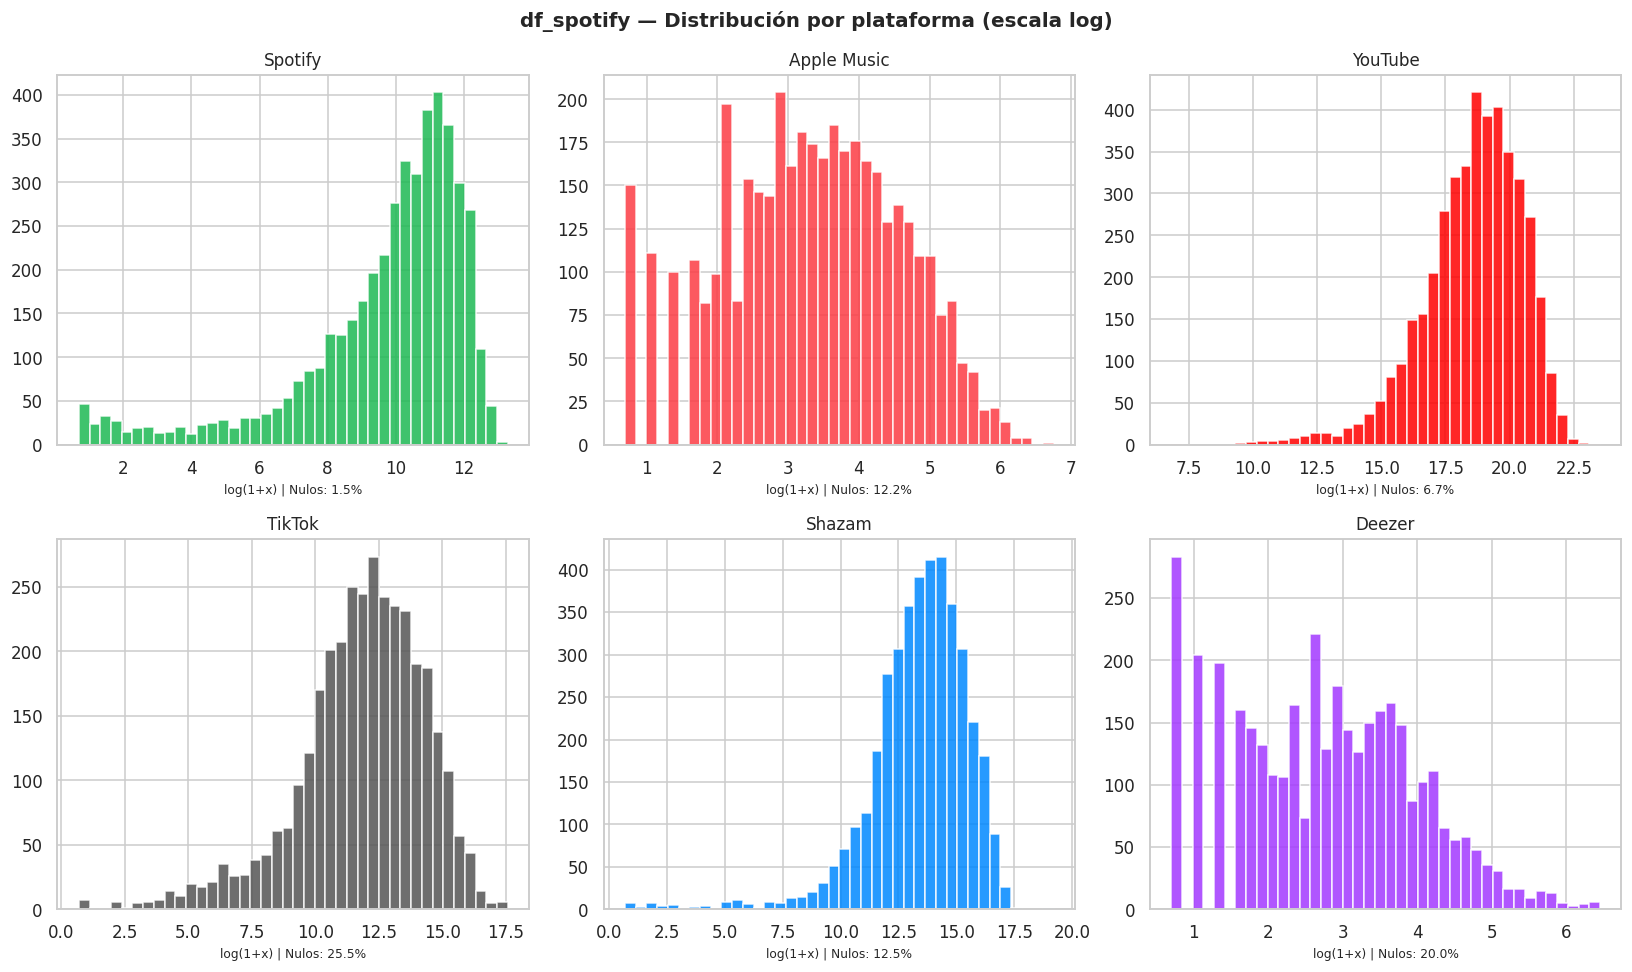

In [ ]:
# Distribución de métricas por plataforma
platform_cols_spotify = {
    'Spotify Playlist Count': ('#1DB954', 'Spotify'),
    'Apple Music Playlist Count': ('#fc3c44', 'Apple Music'),
    'YouTube Views': ('#FF0000', 'YouTube'),
    'TikTok Posts': ('#555555', 'TikTok'),
    'Shazam Counts': ('#0088ff', 'Shazam'),
    'Deezer Playlist Count': ('#a238ff', 'Deezer'),
}
platform_cols_spotify = {k: v for k, v in platform_cols_spotify.items() if k in df_spotify.columns}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (col, (color, name)) in enumerate(platform_cols_spotify.items()):
    ax = axes[i]
    data = np.log1p(df_spotify[col].dropna())
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(name, fontsize=11)
    nulos_pct = df_spotify[col].isnull().mean() * 100
    ax.set_xlabel(f'log(1+x) | Nulos: {nulos_pct:.1f}%', fontsize=8)

plt.suptitle('df_spotify — Distribución por plataforma (escala log)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.7 Outliers — Box plots + IQR

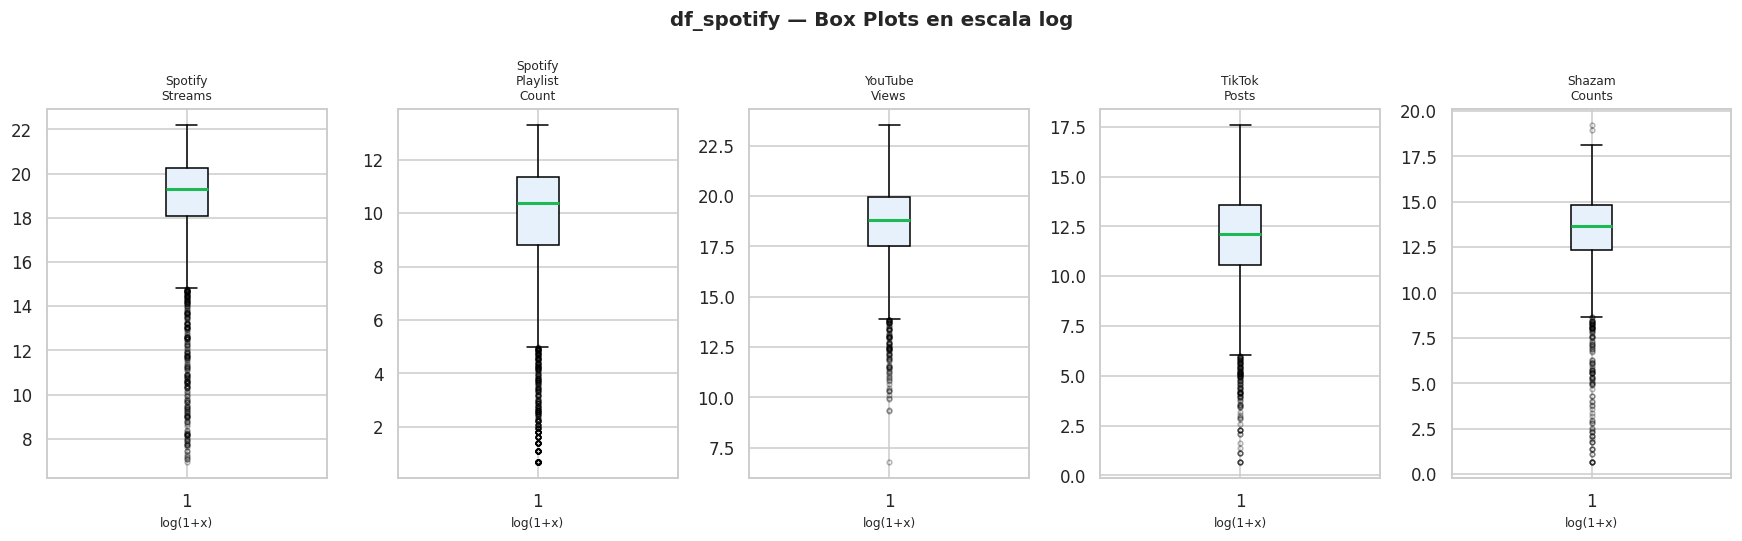


 [df_spotify] Resumen de outliers (método IQR):


,Variable,Q1,Q3,IQR,N Outliers,% Outliers
0,Spotify Streams,70354552.00,6.291025e+08,5.587479e+08,289,6.44
1,Spotify Playlist Count,6705.00,8.608325e+04,7.937825e+04,224,4.95
2,YouTube Views,40756124.25,4.646921e+08,4.239360e+08,422,9.84
3,TikTok Posts,38115.00,7.956030e+05,7.574880e+05,425,12.41
4,Shazam Counts,230133.00,2.686409e+06,2.456276e+06,438,10.89


,Variable,Q1,Q3,IQR,N Outliers,% Outliers
0,Spotify Streams,70354552.00,6.291025e+08,5.587479e+08,289,6.44
1,Spotify Playlist Count,6705.00,8.608325e+04,7.937825e+04,224,4.95
2,YouTube Views,40756124.25,4.646921e+08,4.239360e+08,422,9.84
3,TikTok Posts,38115.00,7.956030e+05,7.574880e+05,425,12.41
4,Shazam Counts,230133.00,2.686409e+06,2.456276e+06,438,10.89


In [ ]:
box_cols_spotify = ['Spotify Streams', 'Spotify Playlist Count',
                    'YouTube Views', 'TikTok Posts', 'Shazam Counts']
box_cols_spotify = [c for c in box_cols_spotify if c in df_spotify.columns]

fig, axes = plt.subplots(1, len(box_cols_spotify), figsize=(16, 5))

for i, col in enumerate(box_cols_spotify):
    ax = axes[i]
    data_log = np.log1p(df_spotify[col].dropna())
    ax.boxplot(data_log, patch_artist=True,
               boxprops=dict(facecolor='#E6F1FB'),
               medianprops=dict(color='#1DB954', linewidth=2),
               flierprops=dict(marker='.', alpha=0.3, color='#D85A30'))
    label = col.replace(' ', '\n')
    ax.set_title(label, fontsize=8)
    ax.set_xlabel('log(1+x)', fontsize=8)

plt.suptitle('df_spotify — Box Plots en escala log', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

resumen_outliers(df_spotify, box_cols_spotify, 'df_spotify')

## 4.8 Correlaciones — Mapa de calor

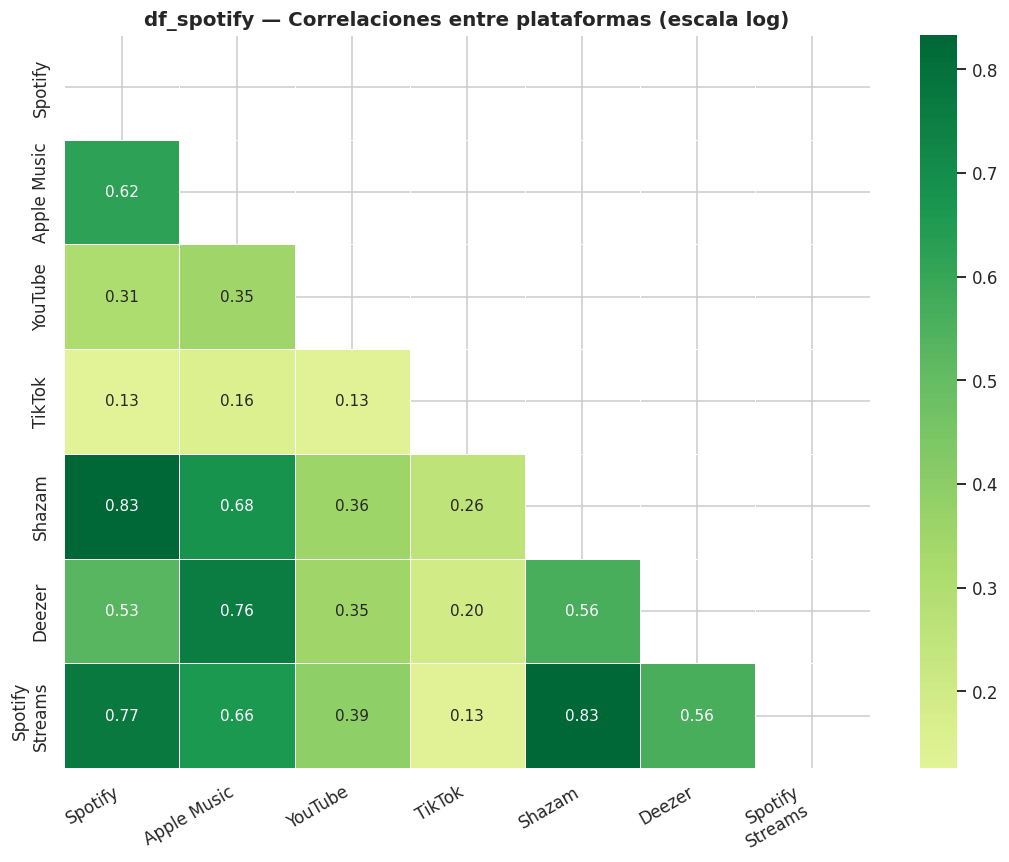


 Correlaciones con Spotify Streams:
Shazam         0.828
Spotify        0.768
Apple Music    0.660
Deezer         0.563
YouTube        0.393
TikTok         0.133
Name: Spotify\nStreams, dtype: object


In [ ]:
corr_cols_spotify = list(platform_cols_spotify.keys()) + [stream_col]
corr_cols_spotify = [c for c in corr_cols_spotify if c in df_spotify.columns]
df_spotify_corr = df_spotify[corr_cols_spotify].apply(np.log1p)

short_spotify = {k: v[1] for k, v in platform_cols_spotify.items()}
short_spotify[stream_col] = 'Spotify\nStreams'
df_spotify_corr.columns = [short_spotify.get(c, c) for c in df_spotify_corr.columns]

corr_spotify = df_spotify_corr.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_spotify, dtype=bool))
sns.heatmap(corr_spotify, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, linecolor='white', annot_kws={'size': 10})
plt.title('df_spotify — Correlaciones entre plataformas (escala log)', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

target_name_sp = short_spotify.get(stream_col, stream_col)
print('\n Correlaciones con Spotify Streams:')
print(corr_spotify[target_name_sp].drop(target_name_sp)
      .sort_values(key=abs, ascending=False).map(lambda x: f'{x:.3f}'))

## 4.9 Análisis por variable target (Spotify Streams)

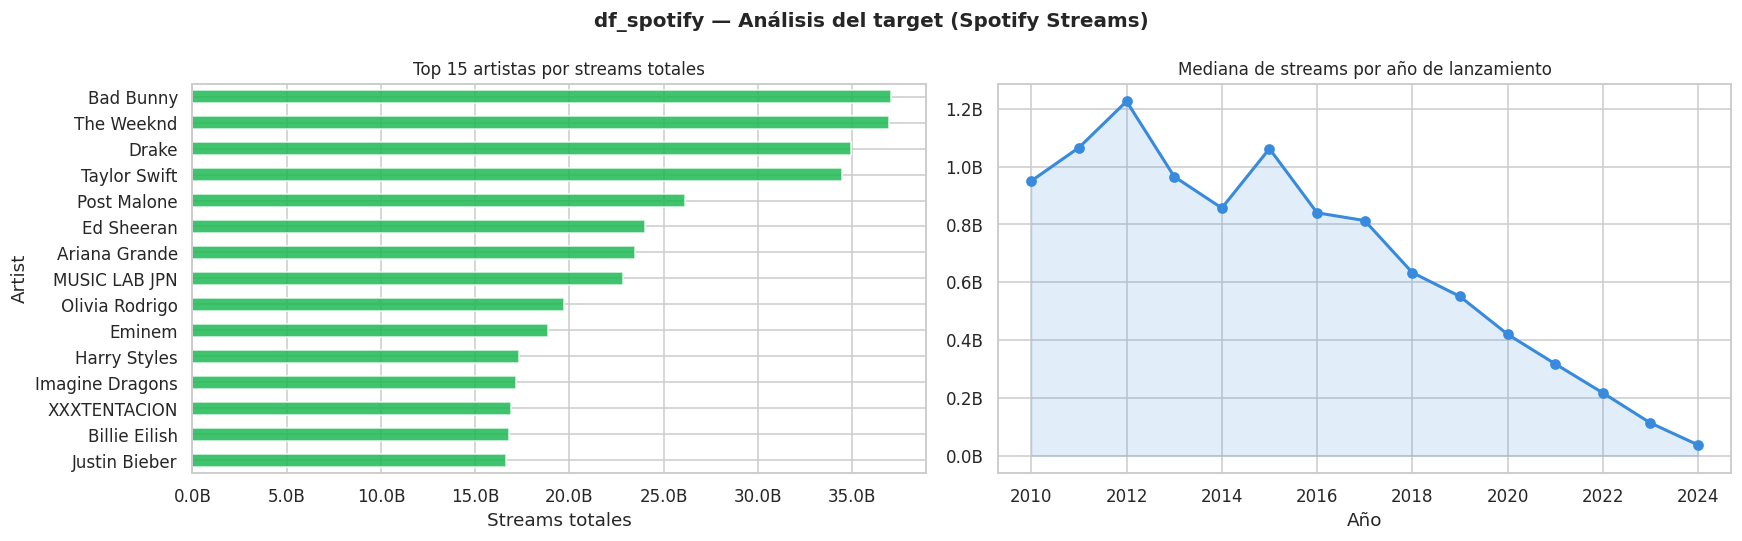


Top 10 canciones por streams:


,Track,Artist,Spotify Streams
0,Blinding Lights,The Weeknd,4.28B
1,Blinding Lights,xSyborg,4.26B
2,Shape of You,Ed Sheeran,3.91B
3,Shape of You,xSyborg,3.89B
4,Someone You Loved,Lewis Capaldi,3.43B
5,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,3.36B
6,As It Was,Harry Styles,3.30B
7,As It Was,Harry Styles,3.30B
8,Starboy,The Weeknd,3.29B
9,One Dance,Drake,3.19B


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 15 artistas
if 'Artist' in df_spotify.columns:
    top_art = df_spotify.groupby('Artist')[stream_col].sum().sort_values().tail(15)
    top_art.plot(kind='barh', ax=axes[0], color='#1DB954', edgecolor='white', alpha=0.85)
    axes[0].set_title('Top 15 artistas por streams totales', fontsize=11)
    axes[0].set_xlabel('Streams totales')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

# Mediana de streams por año
if 'Release Year' in df_spotify.columns:
    yr_sp = df_spotify[df_spotify['Release Year'].between(2010, 2024)]
    yr_med = yr_sp.groupby('Release Year')[stream_col].median()
    yr_med.plot(ax=axes[1], marker='o', color='#378ADD', linewidth=2)
    axes[1].fill_between(yr_med.index, yr_med.values, alpha=0.15, color='#378ADD')
    axes[1].set_title('Mediana de streams por año de lanzamiento', fontsize=11)
    axes[1].set_xlabel('Año')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

plt.suptitle('df_spotify — Análisis del target (Spotify Streams)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 10 canciones por streams:')
top10 = df_spotify.nlargest(10, stream_col)[['Track', 'Artist', stream_col]].copy()
top10[stream_col] = top10[stream_col].map(lambda x: f'{x/1e9:.2f}B')
display(top10.reset_index(drop=True))

## 4.10 Resumen de hallazgos — df_spotify

| Aspecto | Detalle |
|---|---|
| **Tamaño** | aproximadamente 4.600 filas × 29 columnas |
| **Datos sucios** |  15 columnas numéricas almacenadas como strings con comas → convertidas en paso 4.2 |
| **Nulos** | Plataformas secundarias (Pandora, Soundcloud, TIDAL) con nulos esperables |
| **Duplicados** | Verificados y tratados |
| **Outliers** | Extremos en streams; la escala log los normaliza significativamente |
| **Multicolinealidad** | Plataformas altamente correlacionadas entre sí → cuidado en el modelo |
| **Distribución** | Target fuertemente log-normal |
| **Problemática** | **Regresión:** predecir streams de Spotify desde métricas de otras plataformas |
| **Desafío** | Conversión de tipos + multicolinealidad + nulos en plataformas secundarias |